# Praproses Data: Mental Health Pelajar Indonesia


## 1. Import Library & Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', lambda x: '%.3f' % x)
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')

In [2]:
DATA_PATH = './IDN2015_Public_Use_national.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f'Jumlah baris  : {df_raw.shape[0]:,}')
print(f'Jumlah kolom  : {df_raw.shape[1]}')

Jumlah baris  : 11,142
Jumlah kolom  : 141


## 2. Seleksi Fitur

Memilih variabel berdasarkan `VAR_MAP` dari EDA:
- **Demografis**: usia, jenis kelamin, kelas, tinggi, berat
- **Mental health**: kesepian, khawatir, suicidal ideation, teman dekat
- **Bullying & kekerasan**: diserang fisik, perkelahian, hari di-bully
- **Penggunaan zat**: rokok, alkohol, narkoba
- **Aktivitas fisik**: flag aktif fisik
- **Variabel QN binary**: derived variables dari dataset

In [3]:
# Variabel raw
RAW_COLS = {
    # Demografis
    'Q1' : 'usia',
    'Q2' : 'jenis_kelamin',
    'Q3' : 'kelas',
    'Q4' : 'tinggi_m',
    'Q5' : 'berat_kg',
    # Mental health
    'Q22': 'kesepian',
    'Q23': 'khawatir_insomnia',
    'Q24': 'suicidal_ideation_raw',
    'Q25': 'rencana_bunuh_diri',
    'Q26': 'percobaan_bunuh_diri',
    'Q27': 'jumlah_teman',
    # Bullying & kekerasan
    'Q15': 'diserang_fisik',
    'Q16': 'perkelahian_fisik',
    'Q20': 'hari_dibully',
    'Q21': 'cara_dibully',
    # Penggunaan zat
    'Q28': 'usia_mulai_rokok',
    'Q29': 'hari_merokok',
    'Q34': 'usia_mulai_alkohol',
    'Q35': 'hari_minum_alkohol',
    'Q38': 'frek_mabuk',
    'Q40': 'usia_mulai_narkoba',
}

# Variabel QN binary
QN_COLS = {
    'QN22'  : 'flag_kesepian',
    'QN23'  : 'flag_khawatir',
    'QN24'  : 'flag_suicidal',
    'QN25'  : 'flag_rencana_bd',
    'QN26'  : 'flag_percobaan_bd',
    'QN20'  : 'flag_dibully',
    'QN15'  : 'flag_diserang',
    'QN27'  : 'flag_teman_sedikit',
    'QN30'  : 'flag_perokok',
    'QN35'  : 'flag_alkohol',
    'QN42'  : 'flag_narkoba',
    'qnpe3g': 'flag_aktif_fisik',
    'qnpe5g': 'flag_sangat_aktif',
}

all_source_cols = list(RAW_COLS.keys()) + list(QN_COLS.keys())

# Ambil dan rename
df = df_raw[all_source_cols].copy()
df.rename(columns={**RAW_COLS, **QN_COLS}, inplace=True)

print(f'Fitur terpilih : {df.shape[1]} kolom dari {df_raw.shape[1]} kolom asal')
print(f'Jumlah baris   : {df.shape[0]:,}')
print(f'\nDaftar kolom hasil seleksi:')
for col in df.columns:
    print(f'  - {col}')

Fitur terpilih : 34 kolom dari 141 kolom asal
Jumlah baris   : 11,142

Daftar kolom hasil seleksi:
  - usia
  - jenis_kelamin
  - kelas
  - tinggi_m
  - berat_kg
  - kesepian
  - khawatir_insomnia
  - suicidal_ideation_raw
  - rencana_bunuh_diri
  - percobaan_bunuh_diri
  - jumlah_teman
  - diserang_fisik
  - perkelahian_fisik
  - hari_dibully
  - cara_dibully
  - usia_mulai_rokok
  - hari_merokok
  - usia_mulai_alkohol
  - hari_minum_alkohol
  - frek_mabuk
  - usia_mulai_narkoba
  - flag_kesepian
  - flag_khawatir
  - flag_suicidal
  - flag_rencana_bd
  - flag_percobaan_bd
  - flag_dibully
  - flag_diserang
  - flag_teman_sedikit
  - flag_perokok
  - flag_alkohol
  - flag_narkoba
  - flag_aktif_fisik
  - flag_sangat_aktif


## 3. Penanganan Missing Value

### 3.1 Analisis Missing Value

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Jumlah Missing': missing,
    'Persentase (%)': missing_pct
}).sort_values('Persentase (%)', ascending=False)
missing_df = missing_df[missing_df['Jumlah Missing'] > 0]

print(f'Kolom dengan missing value: {len(missing_df)} dari {df.shape[1]}\n')
print(missing_df.to_string())

Kolom dengan missing value: 34 dari 34

                       Jumlah Missing  Persentase (%)
usia_mulai_alkohol                803           7.210
cara_dibully                      783           7.030
hari_dibully                      779           6.990
flag_dibully                      779           6.990
berat_kg                          588           5.280
tinggi_m                          588           5.280
usia_mulai_rokok                  451           4.050
usia_mulai_narkoba                377           3.380
frek_mabuk                        294           2.640
hari_minum_alkohol                221           1.980
flag_alkohol                      221           1.980
flag_aktif_fisik                  182           1.630
flag_sangat_aktif                 182           1.630
flag_suicidal                     165           1.480
suicidal_ideation_raw             165           1.480
hari_merokok                      157           1.410
flag_narkoba                      157     

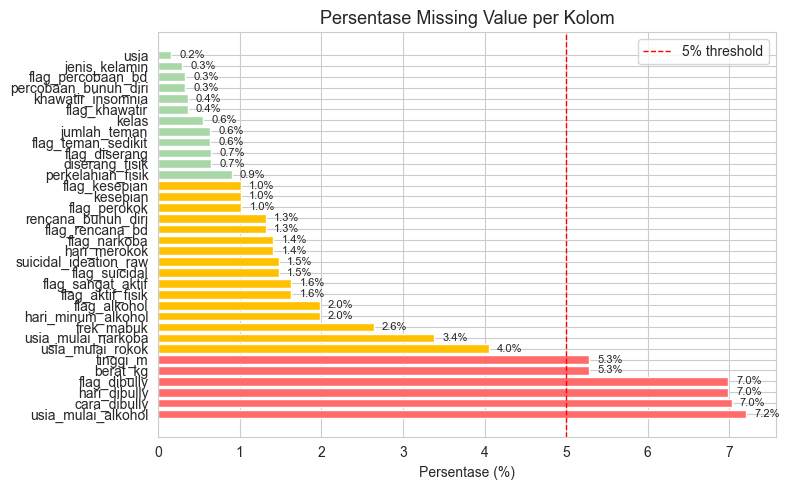

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

# Bar chart missing %
colors_miss = ['#FF6B6B' if v > 5 else '#FFC000' if v > 1 else '#A8D8A8'
               for v in missing_df['Persentase (%)']]

ax.barh(missing_df.index, missing_df['Persentase (%)'],
        color=colors_miss, edgecolor='white')
ax.axvline(x=5, color='red', linestyle='--', linewidth=1, label='5% threshold')
ax.set_title('Persentase Missing Value per Kolom')
ax.set_xlabel('Persentase (%)')
ax.legend()

for i, (idx, row) in enumerate(missing_df.iterrows()):
    ax.text(row['Persentase (%)'] + 0.1, i,
            f"{row['Persentase (%)']:.1f}%", va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 3.2 Drop Baris Target Missing

In [6]:
n_before = len(df)
df = df.dropna(subset=['flag_suicidal'])
n_dropped = n_before - len(df)

print(f'Baris sebelum drop : {n_before:,}')
print(f'Baris dihapus      : {n_dropped} (target QN24 missing)')
print(f'Baris setelah drop : {len(df):,}')
print(f'\nDistribusi target (QN24):')
vc = df['flag_suicidal'].value_counts().sort_index()
print(f'  1 (Ya / suicidal ideation): {vc.get(1.0, 0):,} ({vc.get(1.0,0)/len(df)*100:.2f}%)')
print(f'  2 (Tidak)                 : {vc.get(2.0, 0):,} ({vc.get(2.0,0)/len(df)*100:.2f}%)')

Baris sebelum drop : 11,142
Baris dihapus      : 165 (target QN24 missing)
Baris setelah drop : 10,977

Distribusi target (QN24):
  1 (Ya / suicidal ideation): 604 (5.50%)
  2 (Tidak)                 : 10,373 (94.50%)


### 3.3 Imputasi Missing Value

In [7]:
df_imputed = df.copy()

# Numerik kontinu: MEDIAN
num_cols = ['tinggi_m', 'berat_kg']
for col in num_cols:
    median_val = df_imputed[col].median()
    n_miss = df_imputed[col].isnull().sum()
    df_imputed[col] = df_imputed[col].fillna(median_val)
    print(f'[MEDIAN] {col:20s}: {n_miss} nilai to median={median_val:.3f}')

# Ordinal/kategorikal: MODUS
ordinal_cols = [
    'usia', 'jenis_kelamin', 'kelas',
    'kesepian', 'khawatir_insomnia', 'suicidal_ideation_raw',
    'rencana_bunuh_diri', 'percobaan_bunuh_diri', 'jumlah_teman',
    'diserang_fisik', 'perkelahian_fisik', 'hari_dibully', 'cara_dibully',
    'hari_merokok', 'hari_minum_alkohol', 'frek_mabuk',
    'flag_kesepian', 'flag_khawatir', 'flag_rencana_bd', 'flag_percobaan_bd',
    'flag_dibully', 'flag_diserang', 'flag_teman_sedikit',
    'flag_perokok', 'flag_alkohol', 'flag_narkoba',
    'flag_aktif_fisik', 'flag_sangat_aktif',
]
ordinal_cols = [c for c in ordinal_cols if c in df_imputed.columns]

for col in ordinal_cols:
    n_miss = df_imputed[col].isnull().sum()
    if n_miss > 0:
        mode_val = df_imputed[col].mode()[0]
        df_imputed[col] = df_imputed[col].fillna(mode_val)
        print(f'[MODUS]  {col:25s}: {n_miss} nilai to modus={mode_val}')

# Kolom zat: FILL=1 (tidak pernah)
subst_cols = ['usia_mulai_rokok', 'usia_mulai_alkohol', 'usia_mulai_narkoba']
for col in [c for c in subst_cols if c in df_imputed.columns]:
    n_miss = df_imputed[col].isnull().sum()
    if n_miss > 0:
        df_imputed[col] = df_imputed[col].fillna(1)
        print(f'[FILL=1] {col:25s}: {n_miss} nilai to 1 (tidak pernah)')

print(f'\nTotal missing setelah imputasi: {df_imputed.isnull().sum().sum()}')

[MEDIAN] tinggi_m            : 566 nilai to median=1.520
[MEDIAN] berat_kg            : 566 nilai to median=44.000
[MODUS]  usia                     : 18 nilai to modus=4.0
[MODUS]  jenis_kelamin            : 30 nilai to modus=2.0
[MODUS]  kelas                    : 57 nilai to modus=1.0
[MODUS]  kesepian                 : 78 nilai to modus=1.0
[MODUS]  khawatir_insomnia        : 21 nilai to modus=1.0
[MODUS]  rencana_bunuh_diri       : 72 nilai to modus=2.0
[MODUS]  percobaan_bunuh_diri     : 26 nilai to modus=1.0
[MODUS]  jumlah_teman             : 54 nilai to modus=4.0
[MODUS]  diserang_fisik           : 67 nilai to modus=1.0
[MODUS]  perkelahian_fisik        : 91 nilai to modus=1.0
[MODUS]  hari_dibully             : 744 nilai to modus=1.0
[MODUS]  cara_dibully             : 748 nilai to modus=1.0
[MODUS]  hari_merokok             : 126 nilai to modus=1.0
[MODUS]  hari_minum_alkohol       : 191 nilai to modus=1.0
[MODUS]  frek_mabuk               : 253 nilai to modus=1.0
[MODUS]  f

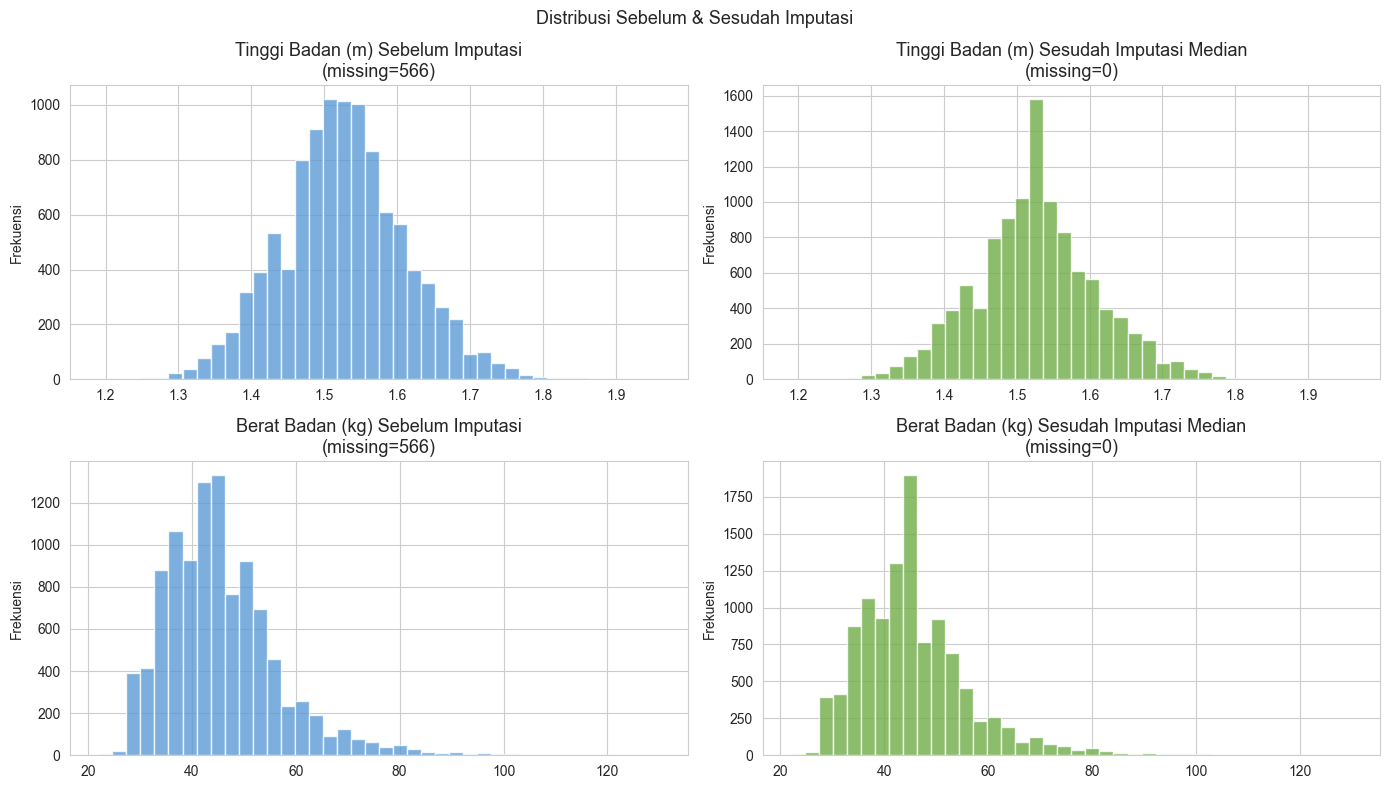

In [8]:
# Visualisasi distribusi sebelum vs sesudah imputasi
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for row_idx, (col, label) in enumerate([('tinggi_m', 'Tinggi Badan (m)'),
                                          ('berat_kg', 'Berat Badan (kg)')]):
    axes[row_idx, 0].hist(df[col].dropna(), bins=40,
                          color='#5B9BD5', edgecolor='white', alpha=0.8)
    axes[row_idx, 0].set_title(f'{label} Sebelum Imputasi\n(missing={df[col].isnull().sum()})')
    axes[row_idx, 0].set_ylabel('Frekuensi')

    axes[row_idx, 1].hist(df_imputed[col], bins=40,
                          color='#70AD47', edgecolor='white', alpha=0.8)
    axes[row_idx, 1].set_title(f'{label} Sesudah Imputasi Median\n(missing=0)')
    axes[row_idx, 1].set_ylabel('Frekuensi')

plt.suptitle('Distribusi Sebelum & Sesudah Imputasi', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Diskretisasi

### 4.1 Diskretisasi BMI

In [9]:
df_prep = df_imputed.copy()

# Hitung BMI
df_prep['bmi'] = df_prep['berat_kg'] / (df_prep['tinggi_m'] ** 2)

# Koreksi outlier BMI
bmi_valid_mask = (df_prep['bmi'] >= 10) & (df_prep['bmi'] <= 50)
n_bmi_outlier = (~bmi_valid_mask).sum()
df_prep.loc[~bmi_valid_mask, 'bmi'] = np.nan
df_prep['bmi'] = df_prep['bmi'].fillna(df_prep['bmi'].median())

print(f'Outlier BMI dikoreksi: {n_bmi_outlier} baris')
print(f'BMI: min={df_prep["bmi"].min():.2f}, mean={df_prep["bmi"].mean():.2f}, max={df_prep["bmi"].max():.2f}')

# Kategorisasi BMI
bins_bmi   = [0, 18.5, 25.0, 30.0, 100]
labels_bmi = ['Underweight', 'Normal', 'Overweight', 'Obese']
df_prep['kategori_bmi'] = pd.cut(df_prep['bmi'], bins=bins_bmi,
                                  labels=labels_bmi, right=False)

print('\nDistribusi Kategori BMI:')
bmi_dist = df_prep['kategori_bmi'].value_counts().reindex(labels_bmi)
for cat, n in bmi_dist.items():
    print(f'  {cat:12s}: {n:5,}  ({n/len(df_prep)*100:.1f}%)')

Outlier BMI dikoreksi: 1 baris
BMI: min=13.01, mean=19.41, max=49.88

Distribusi Kategori BMI:
  Underweight : 4,975  (45.3%)
  Normal      : 5,191  (47.3%)
  Overweight  :   594  (5.4%)
  Obese       :   217  (2.0%)


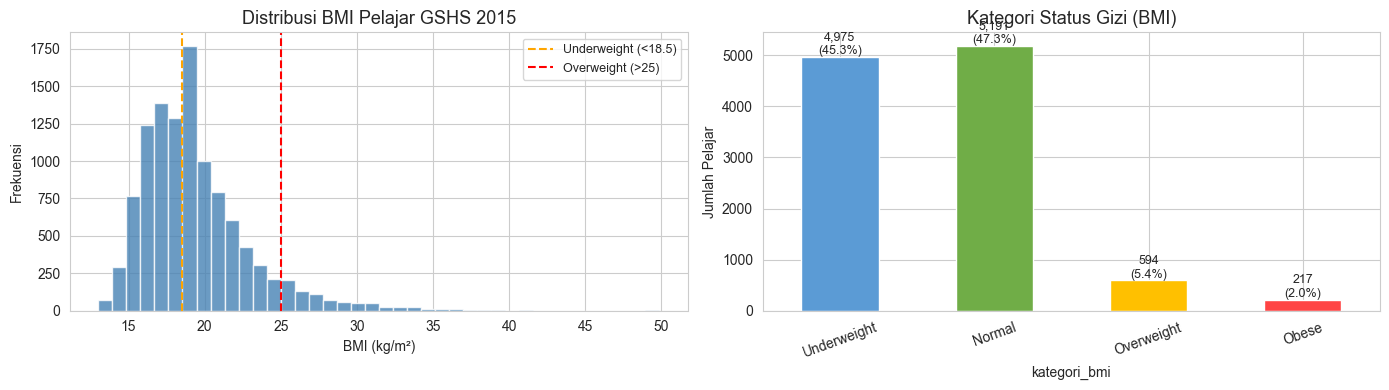

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_prep['bmi'], bins=40, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=18.5, color='orange', linestyle='--', linewidth=1.5, label='Underweight (<18.5)')
axes[0].axvline(x=25.0, color='red',    linestyle='--', linewidth=1.5, label='Overweight (>25)')
axes[0].set_title('Distribusi BMI Pelajar GSHS 2015')
axes[0].set_xlabel('BMI (kg/m²)'); axes[0].set_ylabel('Frekuensi')
axes[0].legend(fontsize=9)

colors_bmi = ['#5B9BD5', '#70AD47', '#FFC000', '#FF4444']
bmi_dist.plot(kind='bar', ax=axes[1], color=colors_bmi, edgecolor='white')
axes[1].set_title('Kategori Status Gizi (BMI)')
axes[1].set_ylabel('Jumlah Pelajar')
axes[1].tick_params(axis='x', rotation=20)
for i, v in enumerate(bmi_dist.values):
    axes[1].text(i, v + 50, f'{v:,}\n({v/len(df_prep)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 4.2 Diskretisasi Usia ke Jenjang Sekolah

In [11]:
# Q1: 1=≤11, 2=12, 3=13, 4=14, 5=15, 6=16, 7=17, 8=≥18
df_prep['jenjang_sekolah'] = df_prep['usia'].apply(
    lambda x: 'SMP (≤13 thn)' if x <= 3 else 'SMA (≥14 thn)'
)
print('Distribusi Jenjang Sekolah:')
print(df_prep['jenjang_sekolah'].value_counts())

Distribusi Jenjang Sekolah:
jenjang_sekolah
SMA (≥14 thn)    6515
SMP (≤13 thn)    4462
Name: count, dtype: int64


### 4.3 Skor Risiko Mental Health Komposit

6 indikator biner: `QN22, QN23, QN24, QN27, QN20, QN15`

In [12]:
risk_flags = ['flag_kesepian', 'flag_khawatir', 'flag_suicidal',
              'flag_teman_sedikit', 'flag_dibully', 'flag_diserang']
risk_flags = [c for c in risk_flags if c in df_prep.columns]

# Konversi 1/2 kr 1/0 sementara untuk menghitung skor
for col in risk_flags:
    df_prep[col + '_num'] = df_prep[col].map({1: 1, 2: 0}).astype(int)

risk_num_cols = [c + '_num' for c in risk_flags]
df_prep['mh_risk_score'] = df_prep[risk_num_cols].sum(axis=1)

# Kategorisasi
df_prep['mh_risk_cat'] = pd.cut(
    df_prep['mh_risk_score'],
    bins=[-1, 0, 1, 2, 6],
    labels=['Tidak Ada Risiko', 'Risiko Rendah', 'Risiko Sedang', 'Risiko Tinggi']
)

# Skor risiko perilaku (rokok, alkohol, narkoba)
beh_flags = ['flag_perokok', 'flag_alkohol', 'flag_narkoba']
for col in [c for c in beh_flags if c in df_prep.columns]:
    df_prep[col + '_num'] = df_prep[col].map({1: 1, 2: 0}).astype(int)
df_prep['behavior_risk_score'] = df_prep[[c + '_num' for c in beh_flags if c in df_prep.columns]].sum(axis=1)

cat_order = ['Tidak Ada Risiko', 'Risiko Rendah', 'Risiko Sedang', 'Risiko Tinggi']
print('Distribusi Skor Risiko MH Komposit:')
score_dist = df_prep['mh_risk_cat'].value_counts().reindex(cat_order)
for cat, n in score_dist.items():
    print(f'  {cat:22s}: {n:5,} ({n/len(df_prep)*100:.1f}%)')

Distribusi Skor Risiko MH Komposit:
  Tidak Ada Risiko      : 5,826 (53.1%)
  Risiko Rendah         : 3,316 (30.2%)
  Risiko Sedang         : 1,358 (12.4%)
  Risiko Tinggi         :   477 (4.3%)


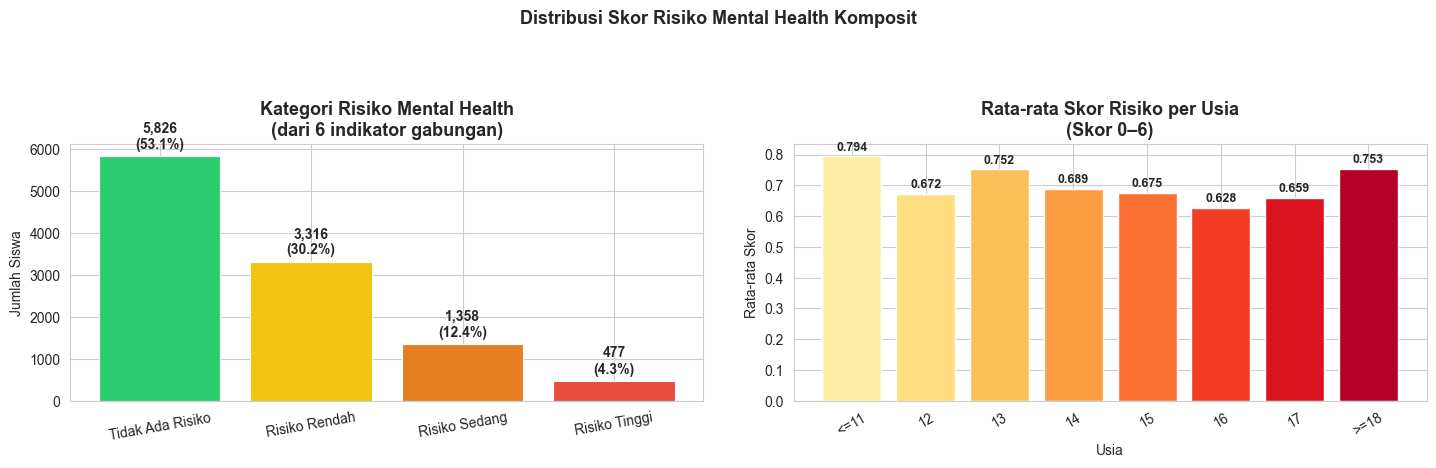

In [13]:
# Visualisasi skor risiko
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Distribusi Skor Risiko Mental Health Komposit', fontsize=13, fontweight='bold')

cat_colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']
total = score_dist.sum()
bars = axes[0].bar(score_dist.index, score_dist.values,
                   color=cat_colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Kategori Risiko Mental Health\n(dari 6 indikator gabungan)', fontweight='bold')
axes[0].set_ylabel('Jumlah Siswa')
axes[0].tick_params(axis='x', rotation=10)
for bar, val in zip(bars, score_dist.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + total*0.01,
                 f'{int(val):,}\n({val/total*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10, fontweight='bold')

usia_label = {1:'<=11',2:'12',3:'13',4:'14',5:'15',6:'16',7:'17',8:'>=18'}
usia_order = ['<=11','12','13','14','15','16','17','>=18']
df_prep['usia_label'] = df_prep['usia'].map(usia_label)
avg_score = df_prep.groupby('usia_label')['mh_risk_score'].mean().reindex(usia_order)
palette_usia = sns.color_palette('YlOrRd', len(usia_order))
bars2 = axes[1].bar(avg_score.index, avg_score.values, color=palette_usia, edgecolor='white')
axes[1].set_title('Rata-rata Skor Risiko per Usia\n(Skor 0–6)', fontweight='bold')
axes[1].set_ylabel('Rata-rata Skor'); axes[1].set_xlabel('Usia')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars2, avg_score.values):
    if not pd.isna(val):
        axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout(pad=3)
plt.show()

## 5. Transformasi & Encoding

### 5.1 Konversi QN Binary (1/2 ke 1/0)

In [14]:
# Semua QN flag: 1=Ya/berisiko, 2=Tidak to 1=Ya, 0=Tidak
qn_flag_cols = [
    'flag_kesepian', 'flag_khawatir', 'flag_suicidal',
    'flag_rencana_bd', 'flag_percobaan_bd', 'flag_dibully',
    'flag_diserang', 'flag_teman_sedikit', 'flag_perokok',
    'flag_alkohol', 'flag_narkoba', 'flag_aktif_fisik', 'flag_sangat_aktif',
]
qn_flag_cols = [c for c in qn_flag_cols if c in df_prep.columns]

for col in qn_flag_cols:
    df_prep[col + '_bin'] = df_prep[col].map({1: 1, 2: 0}).astype(int)

# TARGET biner bersih
df_prep['target'] = df_prep['flag_suicidal'].map({1: 1, 2: 0}).astype(int)

print('Kolom _bin yang dibuat:')
bin_cols = [c + '_bin' for c in qn_flag_cols]
for col in bin_cols:
    n_pos = df_prep[col].sum()
    print(f'  {col:35s}: {n_pos:5,} ({n_pos/len(df_prep)*100:.1f}%)')
print(f'\ntarget (suicidal): {df_prep["target"].sum():,} ({df_prep["target"].mean()*100:.2f}%)')

Kolom _bin yang dibuat:
  flag_kesepian_bin                  :   659 (6.0%)
  flag_khawatir_bin                  :   486 (4.4%)
  flag_suicidal_bin                  :   604 (5.5%)
  flag_rencana_bd_bin                :   603 (5.5%)
  flag_percobaan_bd_bin              :   359 (3.3%)
  flag_dibully_bin                   : 2,064 (18.8%)
  flag_diserang_bin                  : 3,494 (31.8%)
  flag_teman_sedikit_bin             :   303 (2.8%)
  flag_perokok_bin                   :   315 (2.9%)
  flag_alkohol_bin                   :   421 (3.8%)
  flag_narkoba_bin                   :    96 (0.9%)
  flag_aktif_fisik_bin               : 1,421 (12.9%)
  flag_sangat_aktif_bin              :   989 (9.0%)

target (suicidal): 604 (5.50%)


### 5.2 Encoding Variabel Kategorikal

In [15]:
# Jenis kelamin: 1=Laki, 2=Perempuan to 0/1
df_prep['gender_bin'] = (df_prep['jenis_kelamin'] == 2).astype(int)

# Jenjang: SMP=0, SMA=1
df_prep['jenjang_bin'] = (df_prep['jenjang_sekolah'] == 'SMA (≥14 thn)').astype(int)

# BMI kategori: ordinal encoding
bmi_encode = {'Underweight': 0, 'Normal': 1, 'Overweight': 2, 'Obese': 3}
df_prep['bmi_encoded'] = df_prep['kategori_bmi'].map(bmi_encode)

# Kategori risiko: ordinal encoding
risk_encode = {'Tidak Ada Risiko': 0, 'Risiko Rendah': 1,
               'Risiko Sedang': 2, 'Risiko Tinggi': 3}
df_prep['mh_risk_encoded'] = df_prep['mh_risk_cat'].map(risk_encode)

print('Encoding selesai:')
print(f'  gender_bin     : 0={( df_prep["gender_bin"]==0).sum():,}  1={(df_prep["gender_bin"]==1).sum():,}')
print(f'  jenjang_bin    : 0={(df_prep["jenjang_bin"]==0).sum():,}  1={(df_prep["jenjang_bin"]==1).sum():,}')
print(f'  bmi_encoded    : {df_prep["bmi_encoded"].value_counts().sort_index().to_dict()}')
print(f'  mh_risk_encoded: {df_prep["mh_risk_encoded"].value_counts().sort_index().to_dict()}')

Encoding selesai:
  gender_bin     : 0=4,973  1=6,004
  jenjang_bin    : 0=4,462  1=6,515
  bmi_encoded    : {0: 4975, 1: 5191, 2: 594, 3: 217}
  mh_risk_encoded: {0: 5826, 1: 3316, 2: 1358, 3: 477}


## 6. Normalisasi

Min-Max Normalization (range 0-1) pada variabel ordinal dan numerik kontinu

In [16]:
COLS_TO_NORM = [
    'usia', 'kelas', 'bmi',
    'kesepian', 'khawatir_insomnia',
    'diserang_fisik', 'perkelahian_fisik',
    'hari_dibully', 'hari_merokok', 'hari_minum_alkohol', 'frek_mabuk',
    'mh_risk_score', 'behavior_risk_score',
]
COLS_TO_NORM = [c for c in COLS_TO_NORM if c in df_prep.columns]

scaler = MinMaxScaler()
norm_values = scaler.fit_transform(df_prep[COLS_TO_NORM])
norm_col_names = [c + '_norm' for c in COLS_TO_NORM]
df_norm_df = pd.DataFrame(norm_values, columns=norm_col_names, index=df_prep.index)
df_prep = pd.concat([df_prep, df_norm_df], axis=1)

print(f'Kolom yang dinormalisasi ({len(COLS_TO_NORM)}):')
for orig, norm in zip(COLS_TO_NORM, norm_col_names):
    print(f'  {orig:25s} : {norm}')

Kolom yang dinormalisasi (13):
  usia                      : usia_norm
  kelas                     : kelas_norm
  bmi                       : bmi_norm
  kesepian                  : kesepian_norm
  khawatir_insomnia         : khawatir_insomnia_norm
  diserang_fisik            : diserang_fisik_norm
  perkelahian_fisik         : perkelahian_fisik_norm
  hari_dibully              : hari_dibully_norm
  hari_merokok              : hari_merokok_norm
  hari_minum_alkohol        : hari_minum_alkohol_norm
  frek_mabuk                : frek_mabuk_norm
  mh_risk_score             : mh_risk_score_norm
  behavior_risk_score       : behavior_risk_score_norm


## 7. Penanganan Imbalanced Data

Target `QN24` sangat tidak seimbang (~94% Tidak, ~6% Ya).

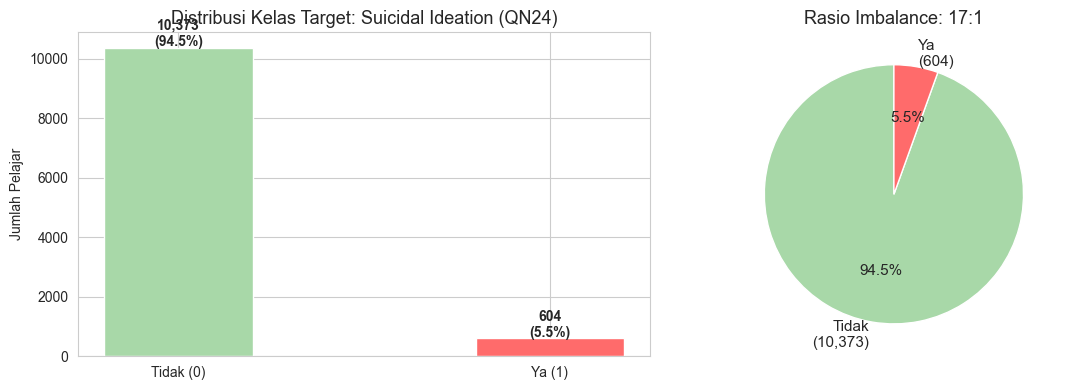

Kelas 0 (Tidak) : 10,373 (94.50%)
Kelas 1 (Ya)    : 604 (5.50%)
Rasio imbalance : 17.2 : 1


In [17]:
target_counts = df_prep['target'].value_counts().sort_index()
imbalance_ratio = target_counts[0] / target_counts[1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Tidak (0)', 'Ya (1)'], target_counts.values,
            color=['#A8D8A8', '#FF6B6B'], edgecolor='white', width=0.4)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df_prep)*100:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Distribusi Kelas Target: Suicidal Ideation (QN24)')
axes[0].set_ylabel('Jumlah Pelajar')

axes[1].pie(target_counts.values,
            labels=[f'Tidak\n({target_counts[0]:,})', f'Ya\n({target_counts[1]:,})'],
            autopct='%1.1f%%', colors=['#A8D8A8', '#FF6B6B'],
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title(f'Rasio Imbalance: {imbalance_ratio:.0f}:1')

plt.tight_layout()
plt.show()

print(f'Kelas 0 (Tidak) : {target_counts[0]:,} ({target_counts[0]/len(df_prep)*100:.2f}%)')
print(f'Kelas 1 (Ya)    : {target_counts[1]:,} ({target_counts[1]/len(df_prep)*100:.2f}%)')
print(f'Rasio imbalance : {imbalance_ratio:.1f} : 1')

In [18]:
# CONTOH
# Demo SMOTE
try:
    from imblearn.over_sampling import SMOTE
    smote_feats = norm_col_names + ['gender_bin', 'jenjang_bin', 'bmi_encoded',
                                     'flag_perokok_bin', 'flag_alkohol_bin',
                                     'flag_narkoba_bin', 'flag_dibully_bin', 'flag_diserang_bin']
    smote_feats = [c for c in smote_feats if c in df_prep.columns]
    X_s = df_prep[smote_feats].fillna(0)
    y_s = df_prep['target']
    X_res, y_res = SMOTE(random_state=42).fit_resample(X_s, y_s)
    print(f'\nDemo SMOTE:')
    print(f'  Sebelum 0: {(y_s==0).sum():,}  1: {(y_s==1).sum():,}')
    print(f'  Sesudah 0: {(y_res==0).sum():,}  1: {(y_res==1).sum():,}')
except ImportError:
    print('\n  [Install imbalanced-learn: pip install imbalanced-learn]')


Demo SMOTE:
  Sebelum 0: 10,373  1: 604
  Sesudah 0: 10,373  1: 10,373


## 8. Simpan Dataset Output

In [19]:
# Dataset 1: Full praproses
df_prep.to_csv('gshs2015_preprocessed_full.csv', index=False)
print(f'[1] gshs2015_preprocessed_full.csv      : {df_prep.shape}')

# Dataset 2: Clustering
clust_feats = (norm_col_names +
               ['gender_bin', 'jenjang_bin', 'bmi_encoded',
                'flag_perokok_bin', 'flag_alkohol_bin', 'flag_narkoba_bin',
                'flag_dibully_bin', 'flag_diserang_bin', 'flag_aktif_fisik_bin',
                'target'])
clust_feats = [c for c in clust_feats if c in df_prep.columns]
df_prep[clust_feats].to_csv('gshs2015_for_clustering.csv', index=False)
print(f'[2] gshs2015_for_clustering.csv         : {df_prep[clust_feats].shape}')

# Dataset 3: Klasifikasi
clf_feats = (['usia', 'gender_bin', 'kelas', 'bmi_encoded', 'jenjang_bin',
              'kesepian', 'khawatir_insomnia', 'jumlah_teman',
              'hari_dibully', 'diserang_fisik', 'perkelahian_fisik',
              'flag_perokok_bin', 'flag_alkohol_bin', 'flag_narkoba_bin',
              'flag_aktif_fisik_bin', 'mh_risk_score', 'behavior_risk_score',
              'target'])
clf_feats = [c for c in clf_feats if c in df_prep.columns]
df_prep[clf_feats].dropna().to_csv('gshs2015_for_classification.csv', index=False)
print(f'[3] gshs2015_for_classification.csv     : {df_prep[clf_feats].dropna().shape}')

# Dataset 4: Association Rule Mining
arm_feats = (['flag_kesepian_bin', 'flag_khawatir_bin', 'flag_rencana_bd_bin',
              'flag_percobaan_bd_bin', 'flag_dibully_bin', 'flag_diserang_bin',
              'flag_perokok_bin', 'flag_alkohol_bin', 'flag_narkoba_bin',
              'flag_aktif_fisik_bin', 'flag_teman_sedikit_bin',
              'gender_bin', 'jenjang_bin', 'target'])
arm_feats = [c for c in arm_feats if c in df_prep.columns]
df_prep[arm_feats].dropna().astype(int).to_csv('gshs2015_for_arm.csv', index=False)
print(f'[4] gshs2015_for_arm.csv                : {df_prep[arm_feats].dropna().shape}')

[1] gshs2015_preprocessed_full.csv      : (10977, 81)
[2] gshs2015_for_clustering.csv         : (10977, 23)
[3] gshs2015_for_classification.csv     : (10977, 18)
[4] gshs2015_for_arm.csv                : (10977, 14)
